Доделанный файл к первому файлу sales_prediction. Рассчитали метрики по дням, по магазинам, общую метрику по моделям

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import xgboost as xgb
from xgboost import XGBRegressor

import shap


In [10]:
def create_predictions(df_train, model):
    # Разделение признаков и целевой переменной
    X = df_train.drop(columns=['log1p'])
    y = df_train['log1p']

    # Разделение на train/test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Импутация пропусков средним значением
    imputer = SimpleImputer(strategy='mean')
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)

    # Обучение модели
    model.fit(X_train_imputed, y_train)

    # Предсказания
    y_pred = model.predict(X_test_imputed)

    # Создание DataFrame с предсказаниями
    predictions_df = pd.DataFrame({
        'actual': y_test,
        'predicted': y_pred
    })

    return predictions_df

# Создаем предсказания для каждой модели
xgb_model = models['XGBoost']
rf_model = models['RandomForest']
lr_model = models['LinearRegression']

# Создаем предсказания
xgb_predictions = create_predictions(df_train, xgb_model)
rf_predictions = create_predictions(df_train, rf_model)
lr_predictions = create_predictions(df_train, lr_model)

# Сохраняем предсказания в CSV
xgb_predictions.to_csv('xgb_predictions.csv', index=False)
rf_predictions.to_csv('rf_predictions.csv', index=False)
lr_predictions.to_csv('lr_predictions.csv', index=False)

print("Предсказания успешно сохранены в файлы: xgb_predictions.csv, rf_predictions.csv, lr_predictions.csv.")

Предсказания успешно сохранены в файлы: xgb_predictions.csv, rf_predictions.csv, lr_predictions.csv.


In [14]:
def train_and_evaluate_models(df_train, target_col='log1p', test_size=0.2, random_state=42):
    """
    Обучает XGBoost, RandomForest и LinearRegression модели на данных df_train.

    Параметры:
    - df_train: pd.DataFrame с признаками и целевой переменной
    - target_col: имя столбца с целевой переменной
    - test_size: доля тестовой выборки
    - random_state: зерно для воспроизводимости

    Возвращает:
    - models: dict с обученными моделями
    - metrics: dict с RMSE для каждой модели на тесте
    """
    # Разделение признаков и целевой переменной
    X = df_train.drop(columns=[target_col])
    y = df_train[target_col]

    # Разделение на train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Импутация пропусков средним значением
    imputer = SimpleImputer(strategy='mean')
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)

    # XGBoost с GridSearchCV
    xgb_model = XGBRegressor(random_state=random_state, objective='reg:squarederror')
    params_xgb = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1]
    }
    grid_xgb = GridSearchCV(xgb_model, params_xgb, cv=3, scoring='neg_root_mean_squared_error', verbose=0)
    grid_xgb.fit(X_train_imputed, y_train)

    # Random Forest с GridSearchCV
    rf_model = RandomForestRegressor(random_state=random_state)
    params_rf = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20]
    }
    grid_rf = GridSearchCV(rf_model, params_rf, cv=3, scoring='neg_root_mean_squared_error', verbose=0)
    grid_rf.fit(X_train_imputed, y_train)

    # Линейная регрессия
    lr_model = LinearRegression()
    lr_model.fit(X_train_imputed, y_train)

    # Оценка моделей
    models = {
        'XGBoost': grid_xgb.best_estimator_,
        'RandomForest': grid_rf.best_estimator_,
        'LinearRegression': lr_model
    }

    metrics = {}
    for name, model in models.items():
        preds = model.predict(X_test_imputed)
        rmse = mean_squared_error(y_test, preds)  # RMSE
        metrics[name] = rmse
        print(f"{name} RMSE: {rmse:.4f}")

    return models, metrics, imputer



In [15]:
def create_predictions_with_shap(df_train, df, model, explainer, imputer, random_state=42):
    # Исходные признаки и целевая переменная
    X = df_train.drop(columns=['log1p'])
    y = df_train['log1p']

    # Разделяем на train/test, сохраняя индексы
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X, y, df_train.index, test_size=0.2, random_state=random_state
    )

    # Импутация
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)

    # Обучаем модель на train
    model.fit(X_train_imputed, y_train)

    # Предсказания на тесте
    y_pred_log = model.predict(X_test_imputed)

    # Обратное преобразование (log1p -> units)
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred_log)

    # SHAP значения
    shap_values = explainer(X_test_imputed)
    shap_abs_sum = np.abs(shap_values.values).sum(axis=1)

    # Возьмем из исходного df_train нужные поля по индексам теста
    df_test = df_train.loc[idx_test].copy()

    # Добавим нужные колонки
    df_test['units'] = y_test_orig.values
    df_test['units_pred'] = y_pred_orig
    df_test['shap'] = shap_abs_sum

    # Добавим prediction_date из исходного df
    df_test['prediction_date'] = df.loc[idx_test, 'date']

    # Переименуем колонки
    df_test = df_test.rename(columns={
        'store_nbr': 'store_code',
        'item_nbr': 'store_item_code',
    })

    # Оставляем только нужные колонки
    cols_needed = ['prediction_date', 'store_code', 'store_item_code', 'units', 'units_pred', 'shap']
    df_final = df_test[cols_needed]

    return df_final



In [17]:
# Обучаем модели
models, metrics, imputer = train_and_evaluate_models(df_train)

# Выбираем лучшую модель (например, XGBoost)
xgb_model = models['XGBoost']

# Создаем SHAP Explainer
explainer = shap.Explainer(xgb_model)

# Формируем итоговый DataFrame с предсказаниями и SHAP
df_predictions = create_predictions_with_shap(df_train, data, xgb_model, explainer, imputer)

# Сохраняем в CSV
df_predictions.to_csv('predictions_with_shap.csv', index=False)

print("Выгрузка с предсказаниями и SHAP сохранена в predictions_with_shap.csv")


XGBoost RMSE: 0.1089
RandomForest RMSE: 0.0981
LinearRegression RMSE: 0.9179
Выгрузка с предсказаниями и SHAP сохранена в predictions_with_shap.csv


In [43]:
prediction_df = pd.read_csv('predictions_with_shap.csv')

In [57]:
prediction_df.head()

,date,store_nbr,item_nbr,units,units_pred,shap
0,2012-03-11,5,93,7.0,3.433039,2.337567
1,2012-07-11,4,101,0.0,0.010807,1.707492
2,2012-01-17,23,29,1.0,2.337565,2.630088
3,2012-04-16,44,105,0.0,-0.000311,1.613073
4,2012-03-02,8,100,0.0,0.001042,1.685363


In [44]:
# Преобразование формата даты
prediction_df['prediction_date'] = pd.to_datetime(prediction_df['prediction_date'])

# Переименование колонок для удобства
prediction_df = prediction_df.rename(columns={
    'prediction_date': 'date',
    'store_code': 'store_nbr',
    'store_item_code': 'item_nbr'
})

# Объединяем с фактическими данными
df_merged = prediction_df.merge(
    data[['date', 'store_nbr', 'item_nbr', 'units']],
    on=['date', 'store_nbr', 'item_nbr'],
    how='left'
)




In [67]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11820 entries, 0 to 11819
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        11820 non-null  datetime64[ns]
 1   store_nbr   11820 non-null  int64         
 2   item_nbr    11820 non-null  int64         
 3   units_x     11820 non-null  float64       
 4   units_pred  11820 non-null  float64       
 5   shap        11820 non-null  float64       
 6   units_y     11820 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 646.5 KB


In [49]:
# Проверка наличия пропусков в фактических продажах
missing_units = df_merged['units_x'].isnull().sum()
print(f"Пропущенных значений фактических продаж: {missing_units}")

Пропущенных значений фактических продаж: 0


In [50]:
# Вычисляем метрики
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_total = np.sqrt(mean_squared_error(df_merged[units_col], df_merged['units_pred']))
r2_total = r2_score(df_merged[units_col], df_merged['units_pred'])

print(f"Общий RMSE: {rmse_total:.4f}")
print(f"Общий R²: {r2_total:.4f}")

Общий RMSE: 15.2053
Общий R²: 0.8621


In [55]:
# Вычисление метрик RMSE и R² по дням
metrics_by_date = df_merged.groupby('date').apply(
    lambda x: pd.Series({
        'rmse': np.sqrt(mean_squared_error(x['units_x'], x['units_pred'])),
        'r2': r2_score(x['units_x'], x['units_pred'])
    })
).reset_index()

print(metrics_by_date.head())



        date       rmse        r2
0 2012-01-01  14.046028  0.895244
1 2012-01-02  17.931768  0.790510
2 2012-01-03  12.459123  0.908519
3 2012-01-04   9.898865  0.937799
4 2012-01-05  14.170780  0.914348


<ipython-input-55-9905b72939bf>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_by_date = df_merged.groupby('date').apply(


In [56]:
# Вычисление метрик RMSE и R² по магазинам
metrics_by_store = df_merged.groupby('store_nbr').apply(
    lambda x: pd.Series({
        'rmse': np.sqrt(mean_squared_error(x['units_x'], x['units_pred'])),
        'r2': r2_score(x['units_x'], x['units_pred'])
    })
).reset_index()

print(metrics_by_store.head())

   store_nbr       rmse        r2
0          1  12.311273  0.509340
1          2  22.654370  0.840618
2          3  12.454781  0.894594
3          4  20.336679  0.756072
4          5   5.167313  0.764172


<ipython-input-56-f2137b9b03b9>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_by_store = df_merged.groupby('store_nbr').apply(


In [64]:
# Список из 10 магазинов для просмотра
store_ids = df_merged['store_nbr'].unique()[:10]  # первые 10 уникальных магазинов

# Фильтруем данные по этим магазинам
df_sample = df_merged[df_merged['store_nbr'].isin(store_ids)]

# Выводим реальные и предсказанные продажи по магазинам и датам
print(df_sample[['store_nbr', 'date', 'units_x', 'units_pred']].sort_values(['store_nbr', 'date']).reset_index(drop=True))


      store_nbr       date  units_x  units_pred
0             1 2012-01-01      0.0   -0.011106
1             1 2012-01-02      0.0    0.014834
2             1 2012-01-04      0.0    0.013933
3             1 2012-01-04      0.0    0.021853
4             1 2012-01-07      0.0    0.007818
...         ...        ...      ...         ...
2675         44 2012-08-21     39.0   48.533130
2676         44 2012-08-21     46.0   47.837890
2677         44 2012-08-22      0.0   -0.002610
2678         44 2012-08-23      0.0   -0.006291
2679         44 2012-08-24      0.0    0.010454

[2680 rows x 4 columns]


In [66]:
# Cуммарные продажи по магазинам
summary = df_sample.groupby('store_nbr').agg({
    'units_x': 'sum',
    'units_pred': 'sum'
}).reset_index()

print(summary)

   store_nbr  units_x   units_pred
0          1   1805.0  1451.121185
1          4   5279.0  3669.754580
2          5   1752.0  1605.278303
3          6   5890.0  5654.490421
4          8   2622.0  2736.319028
5         23   3318.0  3966.028917
6         27   4455.0  4097.273564
7         29   7007.0  6347.233058
8         37   5225.0  5392.098202
9         44   5608.0  4728.493868


In [73]:
import pandas as pd


# Объединяем df_train с данными о погоде из data
df_combined = df_merged.merge(data[['date', 'store_nbr', 'item_nbr', 'tmax', 'tmin', 'snowfall', 'preciptotal', 'is_holiday']],
                              on=['store_nbr', 'item_nbr'], how='left')




In [74]:
# Проверяем, как выглядит объединенный датафрейм
print(df_combined.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2778053 entries, 0 to 2778052
Data columns (total 13 columns):
 #   Column       Dtype         
---  ------       -----         
 0   date_x       datetime64[ns]
 1   store_nbr    int64         
 2   item_nbr     int64         
 3   units_x      float64       
 4   units_pred   float64       
 5   shap         float64       
 6   units_y      int64         
 7   date_y       datetime64[ns]
 8   tmax         float64       
 9   tmin         float64       
 10  snowfall     float64       
 11  preciptotal  float64       
 12  is_holiday   float64       
dtypes: datetime64[ns](2), float64(8), int64(3)
memory usage: 275.5 MB
None


In [76]:
# Добавляем колонку 'weekday' в df_combined
df_combined['weekday'] = df_combined['date_x'].dt.day_name()


In [78]:
# Рассчитываем средние продажи по дням недели
average_sales_by_weekday = df_combined.groupby('weekday')['units_x'].mean()
print(average_sales_by_weekday)



weekday
Friday       21.959126
Monday       21.614514
Saturday     27.530774
Sunday       27.452239
Thursday     19.203983
Tuesday      20.111492
Wednesday    18.393148
Name: units_x, dtype: float64


In [86]:
def calculate_adjustment(row):
    adjustment = 1.0  # базовый коэффициент
    if row['preciptotal'] > 0:  # если есть осадки
        adjustment += 0.1 * row['preciptotal']  # увеличение на 10% за каждую единицу осадков
    adjustment -= 0.05 * row['tmax']  # уменьшение на 5% за каждую единицу максимальной температуры
    return adjustment


In [87]:
# Применяем функцию для расчета коэффициента
df_combined['order_coefficient'] = df_combined.apply(calculate_adjustment, axis=1)

# Применяем коэффициент к предсказанным продажам
df_combined['adjusted_order'] = df_combined['units_x'] * df_combined['order_coefficient']

# Выводим результат
print(df_combined[['store_nbr', 'item_nbr', 'date_x', 'units_x', 'order_coefficient', 'adjusted_order']].head())

   store_nbr  item_nbr     date_x  units_x  order_coefficient  adjusted_order
0          5        93 2012-03-11      7.0             0.9836          6.8852
1          5        93 2012-03-11      7.0             0.9892          6.9244
2          5        93 2012-03-11      7.0             1.0036          7.0252
3          5        93 2012-03-11      7.0             0.9988          6.9916
4          5        93 2012-03-11      7.0             0.9868          6.9076


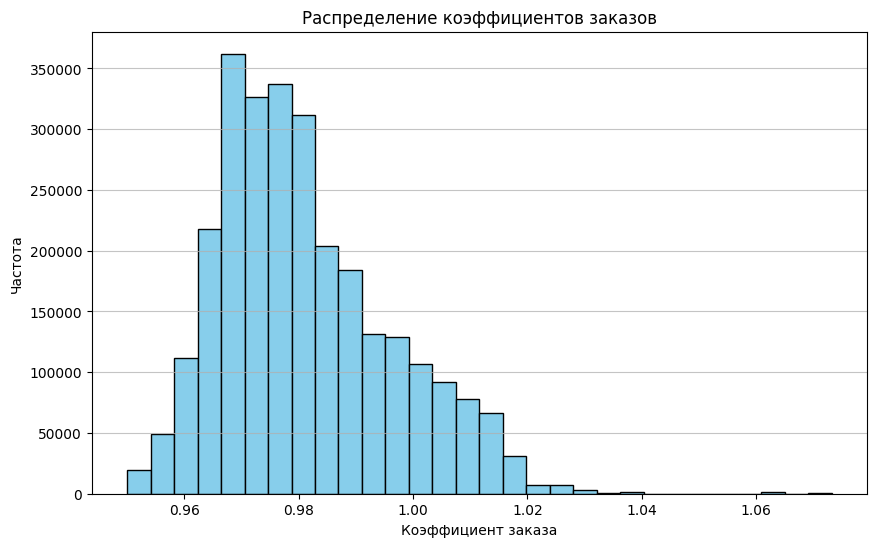

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df_combined['order_coefficient'], bins=30, color='skyblue', edgecolor='black')
plt.title('Распределение коэффициентов заказов')
plt.xlabel('Коэффициент заказа')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.75)
plt.show()


In [89]:
print(df_combined)


            date_x  store_nbr  item_nbr  units_x  units_pred      shap  \
0       2012-03-11          5        93      7.0    3.433039  2.337567   
1       2012-03-11          5        93      7.0    3.433039  2.337567   
2       2012-03-11          5        93      7.0    3.433039  2.337567   
3       2012-03-11          5        93      7.0    3.433039  2.337567   
4       2012-03-11          5        93      7.0    3.433039  2.337567   
...            ...        ...       ...      ...         ...       ...   
2778048 2012-04-12         10         5     64.0   47.462704  2.720007   
2778049 2012-04-12         10         5     64.0   47.462704  2.720007   
2778050 2012-04-12         10         5     64.0   47.462704  2.720007   
2778051 2012-04-12         10         5     64.0   47.462704  2.720007   
2778052 2012-04-12         10         5     64.0   47.462704  2.720007   

         units_y     date_y   tmax      tmin  snowfall  preciptotal  \
0              7 2012-01-01  0.328  0.26

Предыдущие преобразования и предсказания

In [2]:
# Загрузка данных
data = pd.read_csv('data_for_modeling.csv')

# Заполнение пропусков
def fill_missing_values(df):
    columns_with_nans = [
        'avg_temp_last_3_days',
        'avg_precip_last_3_days',
        'season_encoded_cos',
        'day_of_week_sin',
        'day_of_week_cos',
        'month_sin',
        'month_cos'
    ]

    for col in columns_with_nans:
        df[col] = df[col].interpolate(method='time').fillna(method='bfill').fillna(method='ffill')

    return df

# Функция для предобработки данных
def preprocess_data(df):
    df['log1p'] = np.log1p(df['units'])  # Логарифмическое преобразование целевой переменной

    # Преобразование даты
    df['date'] = pd.to_datetime(df['date'])
    df['date2j'] = (df['date'] - pd.to_datetime("2012-01-01")).dt.days  # Дни с начала 2012 года
    # Удаление данных за 2013-12-25 так как там много нулей
    df = df[df['date'] != '2013-12-25']


    # Создание признаков для погоды
    df['preciptotal_flag'] = np.where(df['preciptotal'] > 0.2, 1.0, 0.0)  # Флаг осадков
    df['depart_flag'] = np.where(df['depart'] < -8.0, -1, np.where(df['depart'] > 8.0, 1, 0))

    # Создание временных признаков
    df['weekday'] = df['date'].dt.weekday
    df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)

    df['day'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year

    # Можно еще добавить (предложил GPT)
    # Создание временных признаков
    #df['day_of_week'] = df['date'].dt.dayofweek
    #df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    #df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    #df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    #df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)


    # Агрегация погодных признаков за неделю
    df['week'] = df['date'].dt.isocalendar().week
    if 'temperature' in df.columns and 'precipitation' in df.columns:
        agg_weather = df.groupby(['store_nbr', 'week']).agg({
            'temperature': ['mean', 'max', 'min'],
            'preciptotal': ['sum', 'mean']
        })
        agg_weather.columns = ['_'.join(col) for col in agg_weather.columns]
        agg_weather.reset_index(inplace=True)
        df = df.merge(agg_weather, on=['store_nbr', 'week'], how='left')

        # Взаимодействия признаков(предложил GPT)
        #df['temp_precip_interaction'] = df['temperature_mean'] * df['preciptotal_sum']

    # Кодирование категорий
    #df = pd.get_dummies(df, columns=['store_nbr'], drop_first=True)


    return df

# Препроцессинг данных
data = preprocess_data(data)

# Функция для создания признаков на основе скользящего среднего
def create_rolling_mean(df, window=21): #10 дней до и 10 дней после
    df['rmean'] = df['log1p'].rolling(window=window, center=True).mean()
    df['rmean'] = df['rmean'].interpolate().ffill().bfill()  # Интерполяция и заполнение пропусков
    return df

# Применение функции для создания скользящего среднего
data = create_rolling_mean(data)

# Функция для создания признаков нулевых значений
def create_zero_features(df):
    df['is_zero'] = (df['log1p'] == 0).astype(int)

    # Признаки для последовательных нулей
    for i in range(1, 11):
        df[f'forward_zeros_{i}'] = df['is_zero'].shift(-i).fillna(0).astype(int)
        df[f'backward_zeros_{i}'] = df['is_zero'].shift(i).fillna(0).astype(int)

    df['total_forward_zeros'] = df[[f'forward_zeros_{i}' for i in range(1, 11)]].sum(axis=1)
    df['total_backward_zeros'] = df[[f'backward_zeros_{i}' for i in range(1, 11)]].sum(axis=1)

    return df

# Применение функции для создания признаков нулевых значений
data = create_zero_features(data)

# Создание новых погодных признаков
def create_weather_features(df):
    df['avg_daily_sales_item'] = df['units'].rolling(window=7).mean()  # Пример создания среднего
    return df

# Применение функции для создания погодных признаков
data = create_weather_features(data)

# Сохранение предобработанных данных
data.to_csv('preprocessed_data.csv')




In [3]:
# Функция для создания обучающей выборки
def create_training_data(df):
    # Добавляем новые погодные признаки
    df_train = df[['date', 'store_nbr', 'item_nbr', 'log1p', 'rmean', 'is_zero',
                   'total_forward_zeros', 'total_backward_zeros',
                   'tmax', 'tmin', 'tavg', 'snowfall', 'preciptotal',
                   'is_holiday', 'day_of_week_sin', 'day_of_week_cos',
                   'month_sin', 'month_cos', 'avg_daily_sales_item']]
    return df_train

# Создание обучающей выборки
df_train = create_training_data(data)

# Сохранение обучающей выборки
df_train.to_csv('train_data.csv')

# Загрузка предобработанных данных
df_train = pd.read_csv('train_data.csv')

# Преобразование столбца даты в отдельные числовые признаки
df_train['date'] = pd.to_datetime(df_train['date'])

df_train['year'] = df_train['date'].dt.year
df_train['month'] = df_train['date'].dt.month
df_train['day'] = df_train['date'].dt.day
df_train['weekday'] = df_train['date'].dt.weekday

# Удаление оригинального столбца даты
df_train.drop(columns=['date'], inplace=True)




In [4]:
def train_and_evaluate_models(df_train, target_col='log1p', test_size=0.2, random_state=42):
    """
    Обучает XGBoost, RandomForest и LinearRegression модели на данных df_train.

    Параметры:
    - df_train: DataFrame с признаками и целевой переменной
    - target_col: имя столбца с целевой переменной
    - test_size: доля тестовой выборки
    - random_state: для воспроизводимости

    Возвращает:
    - models: dict с обученными моделями
    - metrics: dict с RMSE для каждой модели на тесте
    """
    # Разделение признаков и целевой переменной
    X = df_train.drop(columns=[target_col])
    y = df_train[target_col]

    # Разделение на train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Заполнение пропусков средним значением
    imputer = SimpleImputer(strategy='mean')
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)

    # XGBoost с GridSearchCV
    xgb_model = XGBRegressor(random_state=random_state, objective='reg:squarederror')
    params_xgb = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1]
    }
    grid_xgb = GridSearchCV(xgb_model, params_xgb, cv=3, scoring='neg_root_mean_squared_error', verbose=0)
    grid_xgb.fit(X_train_imputed, y_train)

    # Random Forest с GridSearchCV
    rf_model = RandomForestRegressor(random_state=random_state)
    params_rf = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20]
    }
    grid_rf = GridSearchCV(rf_model, params_rf, cv=3, scoring='neg_root_mean_squared_error', verbose=0)
    grid_rf.fit(X_train_imputed, y_train)

    # Линейная регрессия
    lr_model = LinearRegression()
    lr_model.fit(X_train_imputed, y_train)

    # Оценка моделей
    models = {
        'XGBoost': grid_xgb.best_estimator_,
        'RandomForest': grid_rf.best_estimator_,
        'LinearRegression': lr_model
    }

    metrics = {}
    for name, model in models.items():
      preds = model.predict(X_test_imputed)
      mse = mean_squared_error(y_test, preds)  # Вычисляем MSE
      rmse = np.sqrt(mse)  # Получаем RMSE
      metrics[name] = rmse
      print(f"{name} RMSE: {rmse:.4f}")

    return models, metrics, imputer

In [5]:
# Импортируем функцию
models, metrics, imputer = train_and_evaluate_models(df_train)

print(metrics)

# Доступ к обученным моделям:
xgb_model = models['XGBoost']
rf_model = models['RandomForest']
lr_model = models['LinearRegression']


XGBoost RMSE: 0.3300
RandomForest RMSE: 0.3132
LinearRegression RMSE: 0.9581
{'XGBoost': np.float64(0.3300321669516792), 'RandomForest': np.float64(0.31323816093823015), 'LinearRegression': np.float64(0.9580543027722416)}


In [6]:
# Коэффициенты линейной регрессии
feature_names = df_train.drop(columns=['log1p']).columns
coefficients = models['LinearRegression'].coef_

for name, coef in zip(feature_names, coefficients):
    print(f"{name}: {coef:.4f}")


Unnamed: 0: 0.0000
store_nbr: 0.0013
item_nbr: -0.0092
rmean: 0.4199
is_zero: -2.4970
total_forward_zeros: 0.0602
total_backward_zeros: 0.1151
tmax: 0.3807
tmin: 0.2008
tavg: -0.3233
snowfall: 0.0809
preciptotal: 0.0098
is_holiday: -0.0026
day_of_week_sin: 0.0017
day_of_week_cos: -0.0172
month_sin: 0.0144
month_cos: -0.0099
avg_daily_sales_item: 0.0154
year: 0.0000
month: -0.3790
day: -0.0110
weekday: -0.0064


In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59098 entries, 0 to 59097
Data columns (total 79 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    59098 non-null  datetime64[ns]
 1   store_nbr               59098 non-null  int64         
 2   item_nbr                59098 non-null  int64         
 3   units                   59098 non-null  int64         
 4   station_nbr             59098 non-null  int64         
 5   tmax                    59098 non-null  float64       
 6   tmin                    59098 non-null  float64       
 7   tavg                    59098 non-null  float64       
 8   depart                  59098 non-null  float64       
 9   snowfall                59098 non-null  float64       
 10  preciptotal             59098 non-null  float64       
 11  stnpressure             59098 non-null  float64       
 12  resultdir               59098 non-null  float6

In [72]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59098 entries, 0 to 59097
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            59098 non-null  int64  
 1   store_nbr             59098 non-null  int64  
 2   item_nbr              59098 non-null  int64  
 3   log1p                 59098 non-null  float64
 4   rmean                 59098 non-null  float64
 5   is_zero               59098 non-null  int64  
 6   total_forward_zeros   59098 non-null  int64  
 7   total_backward_zeros  59098 non-null  int64  
 8   tmax                  59098 non-null  float64
 9   tmin                  59098 non-null  float64
 10  tavg                  59098 non-null  float64
 11  snowfall              59098 non-null  float64
 12  preciptotal           59098 non-null  float64
 13  is_holiday            59097 non-null  float64
 14  day_of_week_sin       59097 non-null  float64
 15  day_of_week_cos    

In [ ]:
import pandas as pd

# Предположим, что у вас уже есть датафреймы `data` и `df_train`

# Объединяем df_train с данными о погоде из data
df_combined = df_train.merge(data[['date', 'store_nbr', 'item_nbr', 'tmax', 'tmin', 'snowfall', 'preciptotal', 'is_holiday']],
                              on=['store_nbr', 'item_nbr'], how='left')

# Проверяем, как выглядит объединенный датафрейм
print(df_combined.info())

# Пример анализа: посмотрим на средние продажи по дням недели
average_sales_by_weekday = df_combined.groupby('weekday')['log1p'].mean()
print(average_sales_by_weekday)

# Пример расчета коэффициента на основе температуры и осадков
def calculate_adjustment(row):
    adjustment = 1.0  # базовый коэффициент
    if row['preciptotal'] > 0:  # если есть осадки
        adjustment += 0.1 * row['preciptotal']  # увеличение на 10% за каждую единицу осадков
    adjustment -= 0.05 * row['tavg']  # уменьшение на 5% за каждую единицу средней температуры
    return adjustment

# Применяем функцию для расчета коэффициента
df_combined['order_coefficient'] = df_combined.apply(calculate_adjustment, axis=1)

# Применяем коэффициент к предсказанным продажам
df_combined['adjusted_order'] = df_combined['log1p'] * df_combined['order_coefficient']

# Выводим результат
print(df_combined[['store_nbr', 'item_nbr', 'date', 'log1p', 'order_coefficient', 'adjusted_order']].head())
